In [1]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import nibabel as nib
import matplotlib.cm as cm  
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.ticker import FuncFormatter

In [2]:
# basepath = "/data/zachkaras/fmri_model_data/intermediate_results"
basepath = "/tank/home/zachkaras/fmri_model_data/intermediate_results"
# basepath = "/s1/fmri_model_data/intermediate_results"

# with open(f"{basepath}/all_results.pkl", 'rb') as f:
#     records = pickle.load(f)
    
with open(f"{basepath}/all_results_regressor+features.pkl", 'rb') as f:
    records = pickle.load(f)

# with open(f"{basepath}/all_results_cosine.pkl", 'rb') as f:
#     records = pickle.load(f)
    
# def nested_dict():
#         return defaultdict(nested_dict)

task_labels = {
    'code' : 'Code',
    'prose' : 'Prose'
}

model_labels = {
    'codegemma_2b' : 'CodeGemma 2B',
    'codegemma_7b' : 'CodeGemma 7B',
    'deepseek_2b'  : 'DeepSeek 2B',
    'deepseek_6b'  : 'DeepSeek 6B',
    'starcoder2_3b': 'StarCoder 3B',
    'starcoder2_7b': 'StarCoder 7B'
}

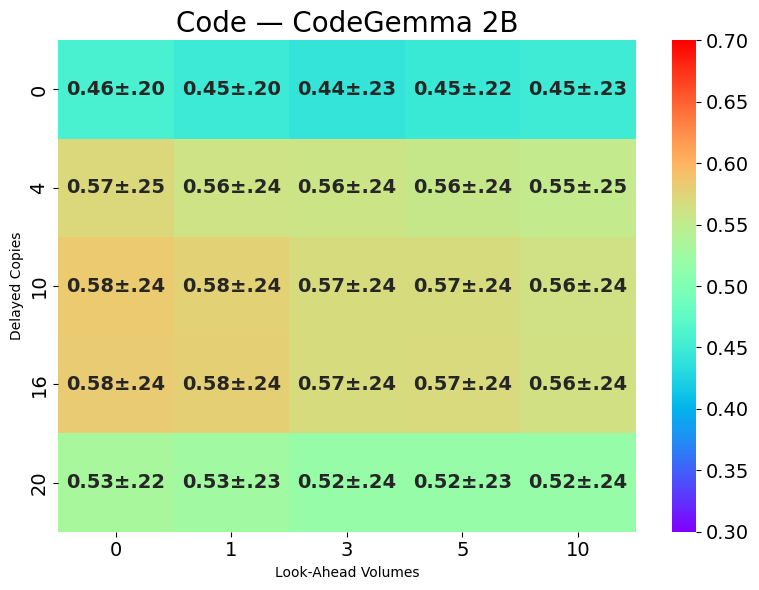

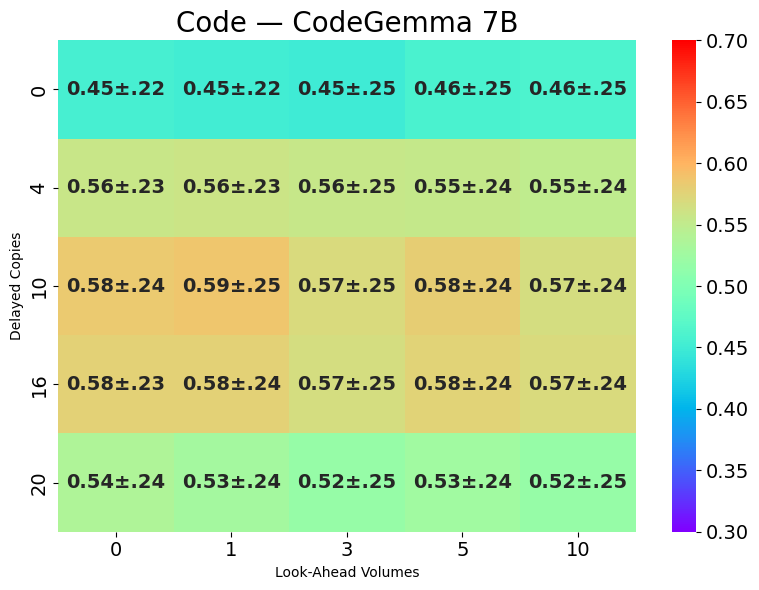

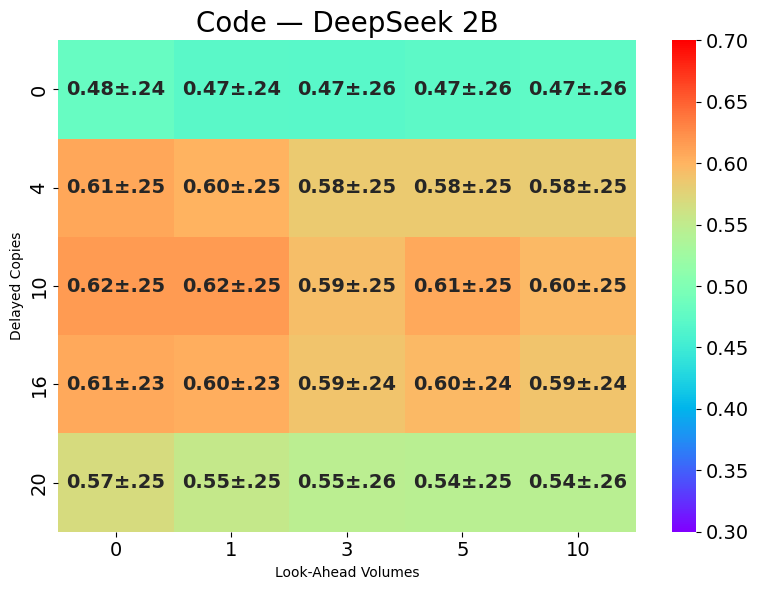

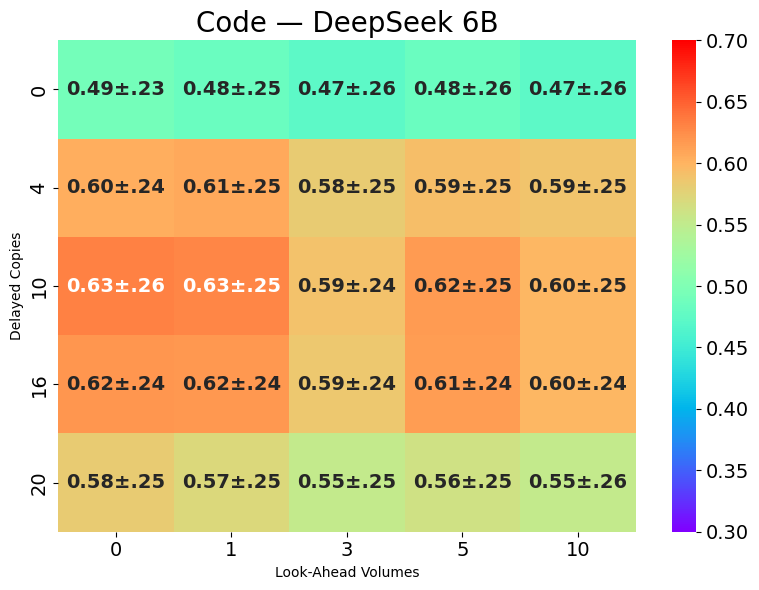

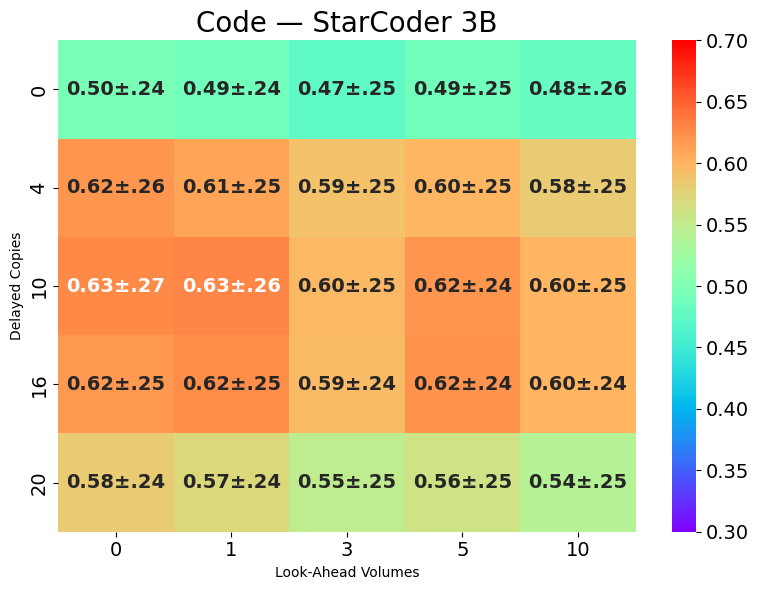

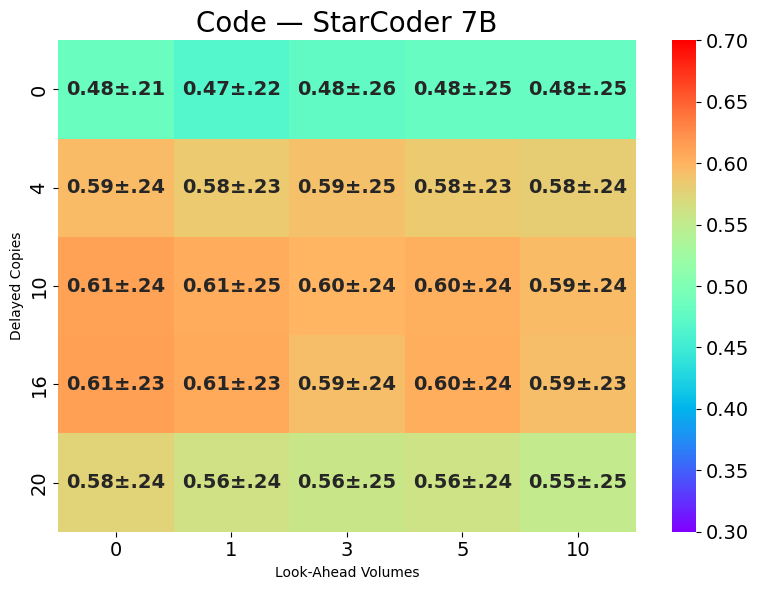

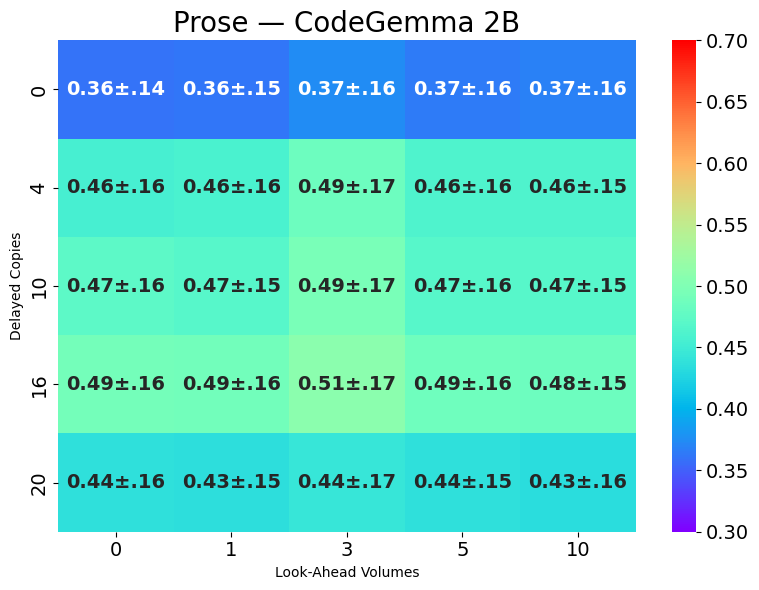

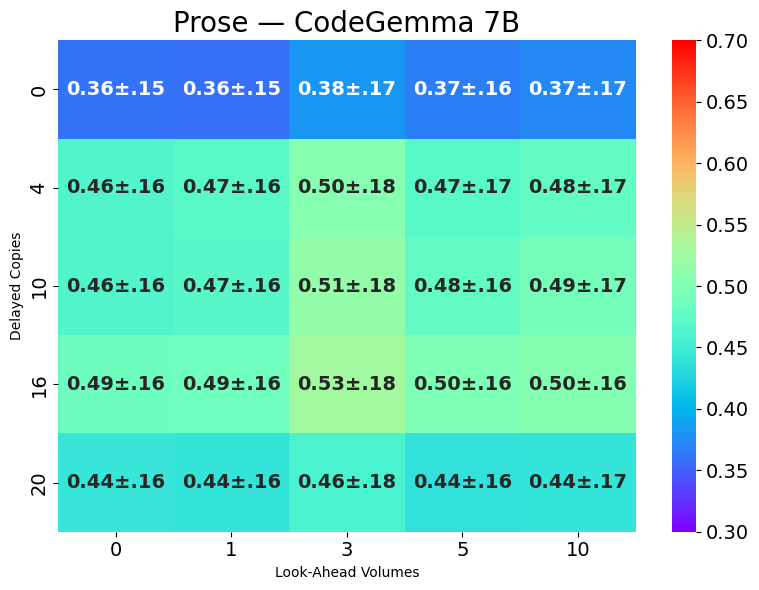

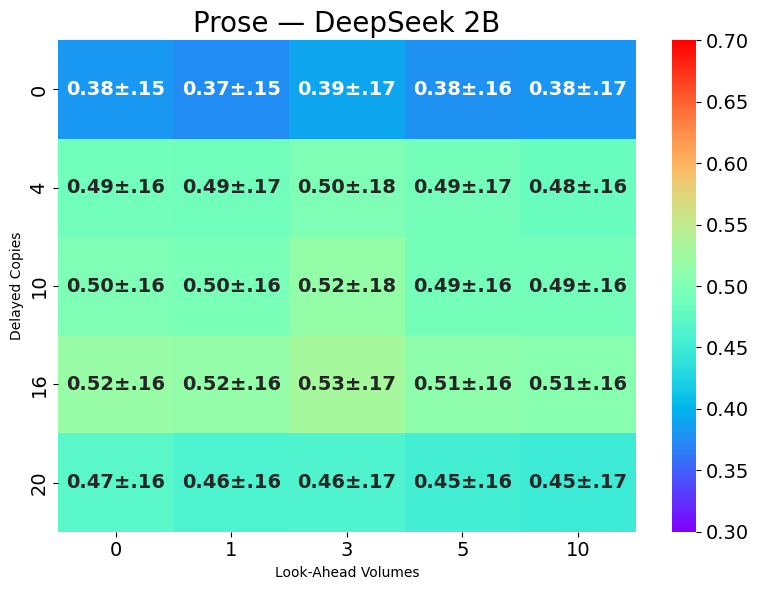

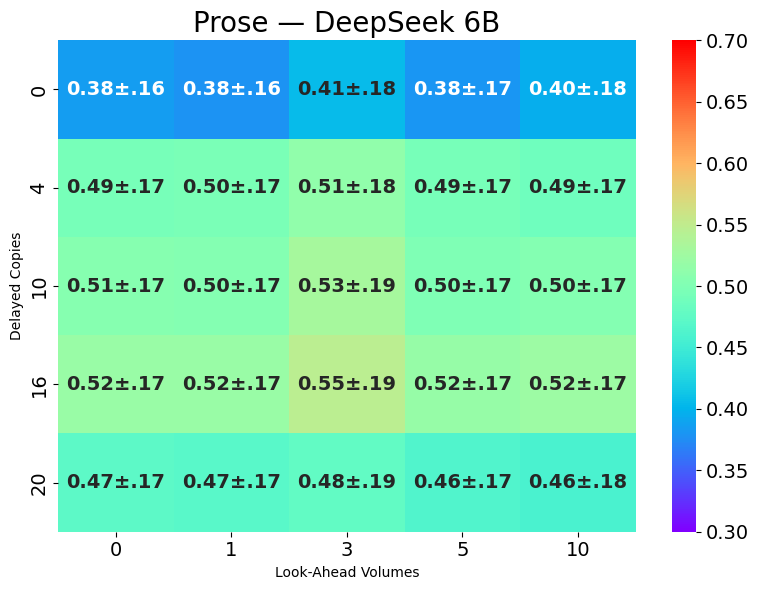

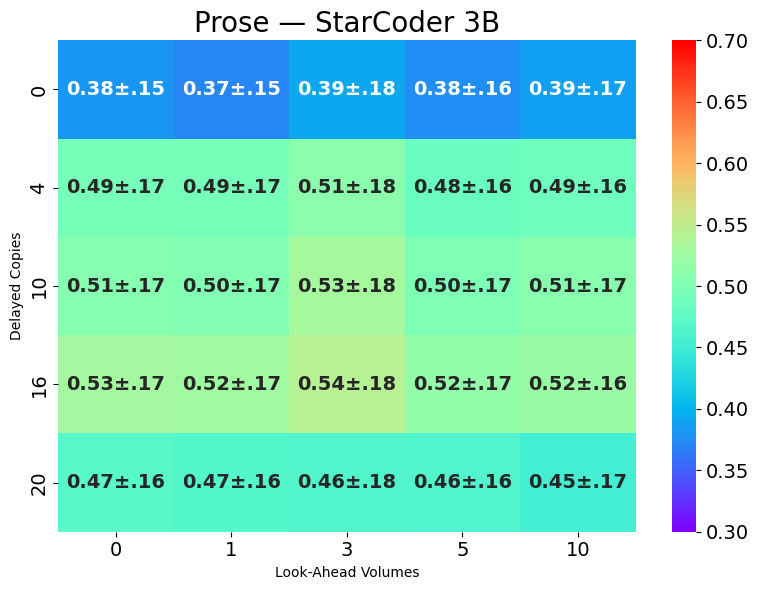

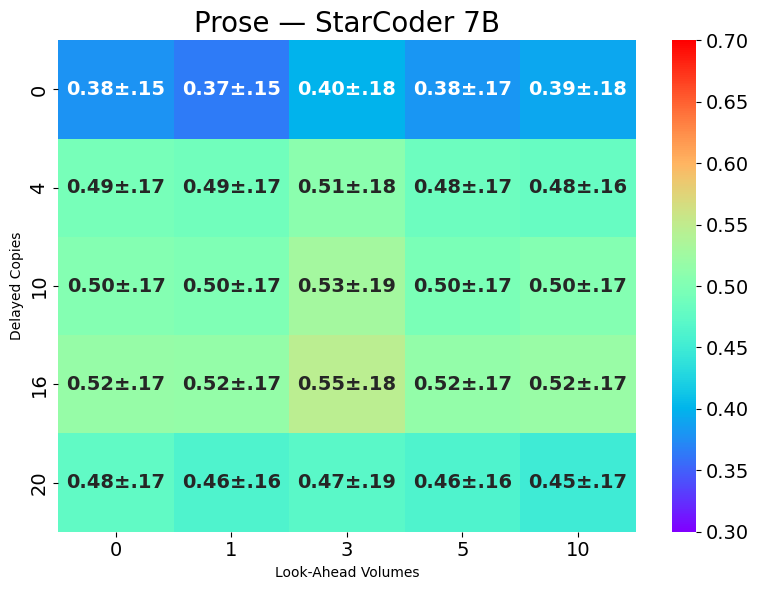

In [3]:

for (task, model), group_df in records.groupby(['task', 'model']):                                                                                                                                         
                                                                                                                                                                                                            
    # Mean participant performance across participants, grouped by the two axes                                                                                                                            
    pivot_mean = np.array(   
        group_df 
        .explode('top_voxel_vals')                                                                                                                                                                                          
        .groupby(['ndelays', 'look_ahead'])['top_voxel_vals']
        .mean()
        .unstack('look_ahead')  # look_ahead becomes columns, ndelays stays as rows
    )
    
    pivot_std = np.array(
        group_df
        .explode('top_voxel_vals')
        .groupby(['ndelays', 'look_ahead'])['top_voxel_vals']
        .std()
        .unstack('look_ahead')
    )
    
    formatted = [[f"{np.array(pivot_mean)[i][j]:.2f}\u00B1{f'{np.array(pivot_std)[i][j]:.2f}'.lstrip('0')}" 
                  for j in range(pivot_mean.shape[0])] 
                 for i in range(pivot_mean.shape[1])]
                                                                                                                                                                                                      

    fig, ax = plt.subplots(figsize=(8, 6))                                                                                                                                                                 
    sns.heatmap(pivot_mean.astype(float), annot=np.array(formatted), annot_kws={"size":14, "weight":"bold"}, fmt= '', cmap='rainbow', ax=ax, vmin=0.3, vmax=0.7)
    ax.set_title(f"{task_labels[task]} — {model_labels[model]}", fontsize=20)
    ax.set_xlabel("Look-Ahead Volumes")                                                                                                                                                                            
    ax.set_xticklabels([0,1,3,5,10], fontsize=14)
    ax.set_ylabel("Delayed Copies")
    ax.set_yticklabels([0,4,10,16,20], fontsize=14)        
    ax.collections[0].colorbar.ax.tick_params(labelsize=14)                                                                                                                                                             
    plt.tight_layout()       
    plt.savefig(f'/tank/home/zachkaras/fmri_model_data/plots/heatmap-{task}-{model}.png', dpi=200)                                                                                                                                                                              
    plt.show()  
    # break

In [4]:
from scipy import stats
Code = 'Code'
Prose = 'Prose'

for model, group_df in records.groupby('model'):
    cell_means = (
        group_df
        .explode('top_voxel_vals')
        .assign(top_voxel_vals=lambda df: df['top_voxel_vals'].astype(float))
        .groupby(['task', 'ndelays', 'look_ahead'])['top_voxel_vals']
        .mean()
        .unstack('task')
    )

    if 'code' not in cell_means.columns or 'prose' not in cell_means.columns:
        continue

    paired = cell_means[['code', 'prose']].dropna()
    t, p = stats.ttest_rel(paired['code'], paired['prose'])
    diff = paired['code'] - paired['prose']
    cohens_d = diff.mean() / diff.std()
    print(f"{model_labels[model]} ($t={t:.3f}$, $p={p:.3f}$, $d={cohens_d:.3f}$, $\\mu_{{Code}}={paired['code'].mean():.3f}$, $\\sigma_{{Code}}={paired['code'].std():.3f}$, $\\mu_{{Prose}}={paired['prose'].mean():.3f}$, $\\sigma_{{Prose}}={paired['prose'].std():.3f}$), ") 


CodeGemma 2B ($t=31.999$, $p=0.000$, $d=6.400$, $\mu_{Code}=0.535$, $\sigma_{Code}=0.049$, $\mu_{Prose}=0.447$, $\sigma_{Prose}=0.046$), 
CodeGemma 7B ($t=21.646$, $p=0.000$, $d=4.329$, $\mu_{Code}=0.537$, $\sigma_{Code}=0.046$, $\mu_{Prose}=0.454$, $\sigma_{Prose}=0.050$), 
DeepSeek 2B ($t=32.093$, $p=0.000$, $d=6.419$, $\mu_{Code}=0.564$, $\sigma_{Code}=0.051$, $\mu_{Prose}=0.469$, $\sigma_{Prose}=0.050$), 
DeepSeek 6B ($t=22.769$, $p=0.000$, $d=4.554$, $\mu_{Code}=0.572$, $\sigma_{Code}=0.051$, $\mu_{Prose}=0.478$, $\sigma_{Prose}=0.050$), 
StarCoder 3B ($t=25.803$, $p=0.000$, $d=5.161$, $\mu_{Code}=0.575$, $\sigma_{Code}=0.051$, $\mu_{Prose}=0.474$, $\sigma_{Prose}=0.053$), 
StarCoder 7B ($t=32.782$, $p=0.000$, $d=6.556$, $\mu_{Code}=0.566$, $\sigma_{Code}=0.048$, $\mu_{Prose}=0.474$, $\sigma_{Prose}=0.052$), 


### Performance by layer, model, participant

In [5]:
participant_means = {
    'code' : {},
    'prose': {}
}

# by participant
def participant_index(id):
    return (np.where(demo_data['id'] == int(id)))[0][0]

demo_data = pd.read_csv("/tank/home/zachkaras/fmri_model/master-survey-data.csv")

task_colors = {'code': '#8000ffff', 'prose': '#82ffb4'}

# for (p,task), df in records.groupby(['participant','task']):
# mask = (                                                                                                                                                                                                  
#       ((records['task'] == 'prose') & (records['look_ahead'] == 'look_ahead_by_3') & (records['ndelays'] == 'ndelays_16')) |                                                                                
#       ((records['task'] == 'code')  & (records['look_ahead'] == 'look_ahead_by_1') & (records['ndelays'] == 'ndelays_10'))                                                                                  
#   )  
# for (model, p, layer, task, delays, look_ahead), df in records[mask].groupby(['model', 'participant', 'layer', 'task', 'ndelays', 'look_ahead']):
for (model, p, layer, task, delays, look_ahead), df in records.groupby(['model', 'participant', 'layer', 'task', 'ndelays', 'look_ahead']):
    # if delays != 'ndelays_10' or look_ahead != 'look_ahead_by_1':
    #     continue
    mean_val = df['top_voxel_vals'].explode().mean()
    participant_means[task][p] = mean_val


/tmp/ipykernel_2888104/1604048870.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=90)


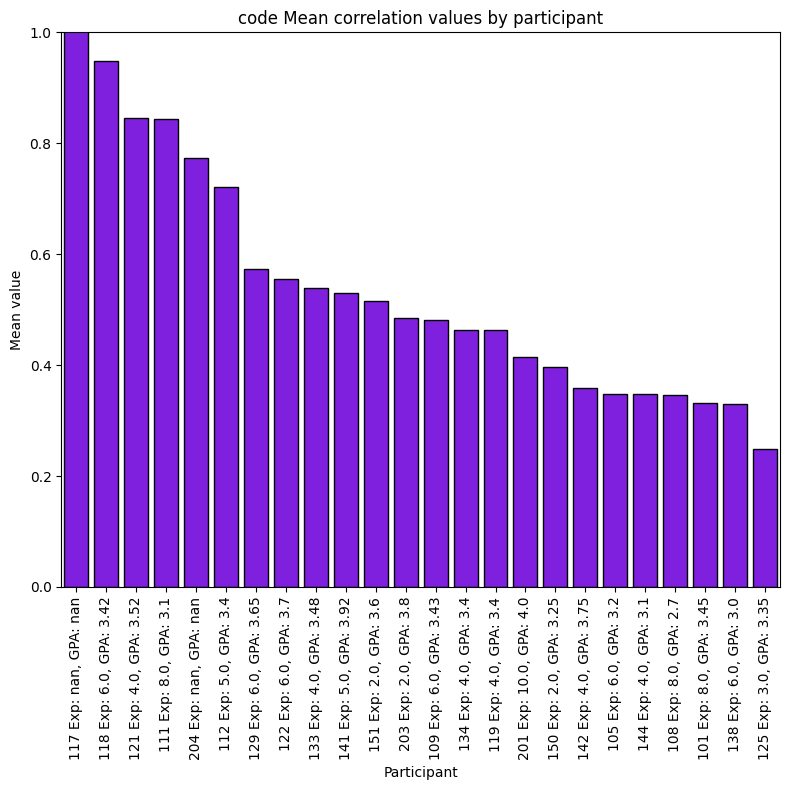

/tmp/ipykernel_2888104/1604048870.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=90)


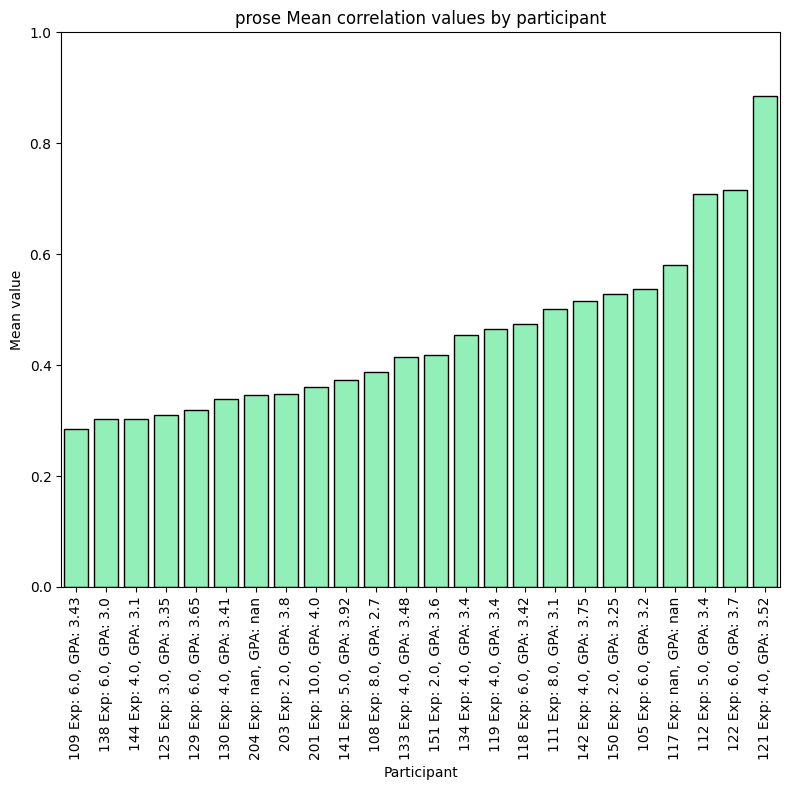

In [6]:
for task in ['code', 'prose']:
    if task == 'code':
        sorted_means = dict(sorted(participant_means[task].items(), key=lambda x: x[1], reverse=True))
        labels = list(sorted_means.keys())
    else:
        sorted_means = dict(sorted(participant_means[task].items(), key=lambda x: x[1]))
        labels = list(sorted_means.keys())
    
    # Semesters experience and GPA
    labels = [f"{l} Exp: {demo_data.loc[participant_index(l), 'semesters_experience']}, GPA: {demo_data.loc[participant_index(l), 'GPA']}" for l in labels]

    means = list(sorted_means.values())
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 8))
    sns.barplot(x=labels, y=means, color=task_colors[task], edgecolor='black', ax=ax)
    ax.set_ylabel("Mean value")
    ax.set_xlabel("Participant")
    ax.set_xticklabels(labels, rotation=90)
    ax.set_ylim([0.0, 1])
    ax.set_title(f"{task} Mean correlation values by participant")
    plt.tight_layout()
    # plt.savefig(f"/data/zachkaras/fmri_model_data/plots/participant_bar_graph-{task}.png", dpi=200)
    plt.show()

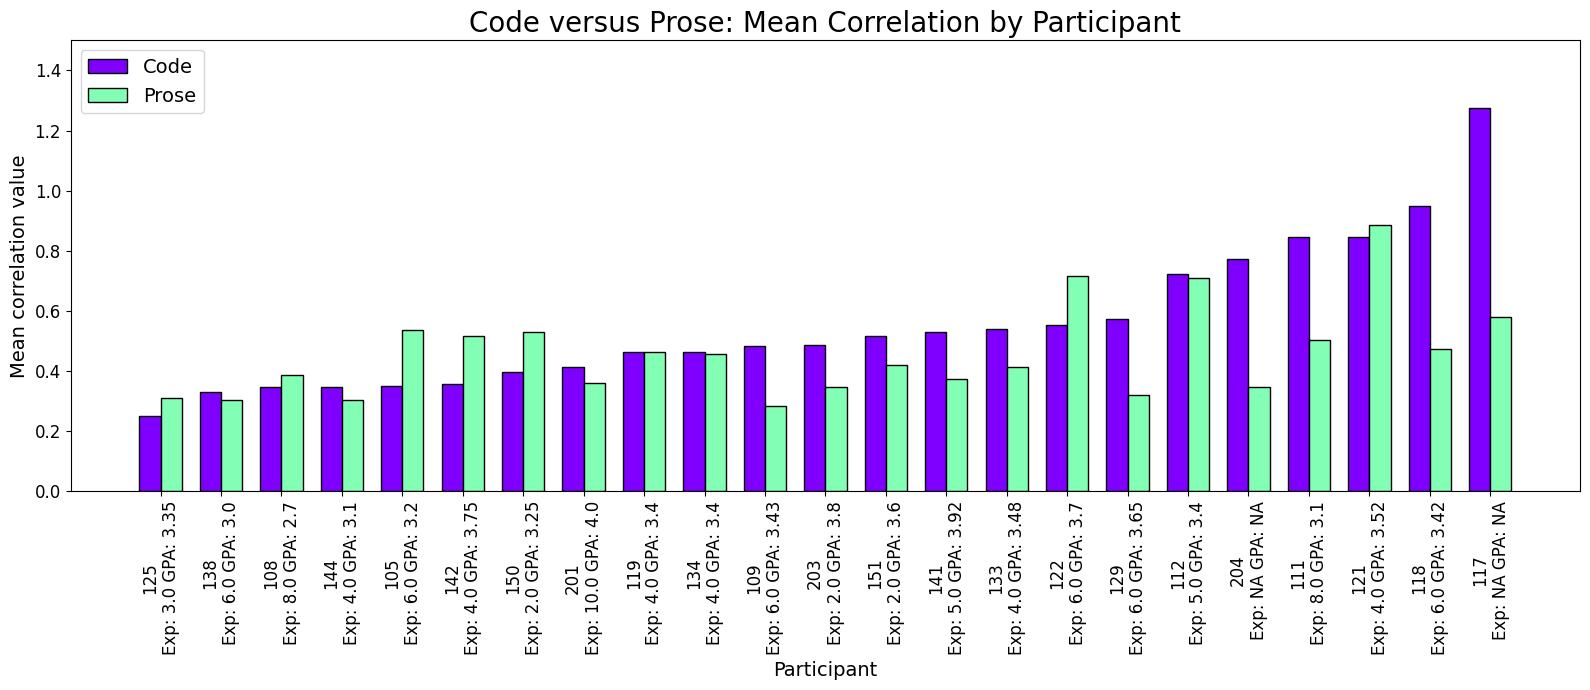

In [7]:
# Grouped bar chart: code vs prose side by side per participant
common_pids = [pid for pid in participant_means['code'] if pid in participant_means['prose']]
common_pids_sorted = sorted(common_pids, key=lambda p: participant_means['code'][p]) #, reverse=True)

code_vals  = [participant_means['code'][pid]  for pid in common_pids_sorted]
prose_vals = [participant_means['prose'][pid] for pid in common_pids_sorted]
labels = [
    f"{p}\nExp: {demo_data.loc[participant_index(p), 'semesters_experience']} GPA: {demo_data.loc[participant_index(p), 'GPA']}"
    for p in common_pids_sorted
]
labels = [re.sub('nan', 'NA', l) for l in labels]

x = np.arange(len(common_pids_sorted))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 7))
ax.bar(x - width / 2, code_vals,  width, label='Code',  color=task_colors['code'],  edgecolor='black')
ax.bar(x + width / 2, prose_vals, width, label='Prose', color=task_colors['prose'], edgecolor='black')

ax.set_ylabel("Mean correlation value", fontsize=14)
ax.set_xlabel("Participant", fontsize=14)
ax.set_title("Code versus Prose: Mean Correlation by Participant", fontsize=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim([0.0, 1.5])
ax.legend(prop={'size':14}, loc='upper left')
plt.tight_layout()
plt.savefig("/tank/home/zachkaras/fmri_model_data/plots/participant_bar_graph_grouped.png", dpi=200)
plt.show()

In [8]:
with open("/tank/home/zachkaras/fmri_model_data/intermediate_results/participant_means.pkl", 'wb') as f:
    pickle.dump(participant_means, f)

In [9]:
from scipy import stats

common_pids = [pid for pid in participant_means['code'] if pid in participant_means['prose']]
code_vals  = np.array([participant_means['code'][pid]  for pid in common_pids])
prose_vals = np.array([participant_means['prose'][pid] for pid in common_pids])

t, p = stats.ttest_rel(code_vals, prose_vals)
# print(f"n={len(common_pids)} participants: t={t:.3f}, p={p}  |  code={code_vals.mean():.3f}, prose={prose_vals.mean():.3f}")
print(f"($t={t:.3f}$, $p={p:.3f}$, $\\mu_{{Code}}={code_vals.mean():.3f}$, $\\sigma_{{Code}}={code_vals.std():.3f}$, $\\mu_{{Prose}}={prose_vals.mean():.3f}$, $\\sigma_{{Prose}}={prose_vals.std():.3f}$)")


($t=2.149$, $p=0.043$, $\mu_{Code}=0.557$, $\sigma_{Code}=0.238$, $\mu_{Prose}=0.458$, $\sigma_{Prose}=0.149$)


In [10]:
def compute_layer_means(this_task):
    layer_means = {}
    for (model, layer, task, delays, look_ahead), df in records.groupby(['model', 'layer', 'task', 'ndelays', 'look_ahead']):
        # TODO - check whether we should filter to specific parameter options
        if task != this_task: # or delays != 'ndelays_10' or look_ahead != 'look_ahead_by_1':
            continue
        layer_mean = df['top_voxel_vals'].explode().mean()
        if model not in layer_means.keys():
            layer_means[model] = {layer : layer_mean}
        else:
            layer_means[model][layer] = layer_mean
        # print(model, layer, layer_mean)
    
    for model,layers in layer_means.items():
        l = sorted(layers.keys(), key=lambda x: int(x.split('_')[1]))
        # print(f"{model}_layers = {l}")
        
    del layer_means['codegemma_2b']['layer_2']
    del layer_means['codegemma_2b']['layer_8']
    del layer_means['deepseek_2b']['layer_15']
    del layer_means['deepseek_6b']['layer_20']
    del layer_means['starcoder2_7b']['layer_24']
    
    for model,layers in layer_means.items():
        l = sorted(layers.keys(), key=lambda x: int(x.split('_')[1]))
        # print(f"{model}_layers = {l}")
    
    return layer_means

def plot_layer_means(layer_means, task):                                                                                                                                                                              
    n = len(list(layer_means['deepseek_2b']))
    palette = [cm.rainbow(x) for x in np.linspace(0, 1, n)]   
    rng = np.random.default_rng(seed=747)                                                                                                                                                                      
    rng.shuffle(palette)

    rows = []
    for model, layerScores in layer_means.items():
        sorted_layers = sorted(layerScores.keys(), key=lambda x: int(x.split('_')[1]))
        for idx, layer in enumerate(sorted_layers):
            rows.append({'model': model, 'layer_idx': idx, 'layer': layer, 'score': layerScores[layer]})
    df = pd.DataFrame(rows)


    n_layers = len(list(layer_means['deepseek_2b'].keys()))
    hue_order = list(range(n_layers))


    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(data=df, x='model', y='score', hue='layer_idx', hue_order=hue_order,
                edgecolor='black', ax=ax, palette=palette)
    model_names = [t.get_text() for t in ax.get_xticklabels()]                                                                                                                                                                                                                                                                     
    model_names = [model_labels[m] for m in model_names]   

    ax.set_xlabel("Model", fontsize=14)
    ax.set_ylim([0.0, 0.7])
    ax.set_ylabel("Mean Correlation Value", fontsize=14)
    ax.set_title(f"{task} Correlation Averages by Layer", fontsize=20)
    ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=12)
    legend = ax.legend(title="Relative Layer\nIndex", loc='lower right')
    legend.get_title().set_multialignment('center')
    plt.tight_layout()
    plt.savefig(f"/tank/home/zachkaras/fmri_model_data/plots/layer_correlations-{task}.png", dpi=200)
    plt.show()
    

def compute_layer_stats(layer_means, task):
    # Same filters used to build layer_means
    print(task)
    mask = (
        (records['task'] == task) #&
        # (records['ndelays'] == 'ndelays_10') &
        # (records['look_ahead'] == 'look_ahead_by_1')
    )

    for model, group_df in records[mask].groupby('model'):
        # Per-participant mean per layer
        layer_participant_means = (
            group_df
            .explode('top_voxel_vals')
            .assign(top_voxel_vals=lambda df: df['top_voxel_vals'].astype(float))
            .groupby(['layer', 'participant'])['top_voxel_vals']
            .mean()
        )

        # Collect groups in layer order, skipping deleted layers
        sorted_layers = sorted(
            layer_participant_means.index.get_level_values('layer').unique(),
            key=lambda x: int(x.split('_')[1])
        )
        groups = []
        kept_layers = []
        for layer in sorted_layers:
            if layer not in layer_means.get(model, {}):
                continue
            groups.append(layer_participant_means.xs(layer, level='layer').values)
            kept_layers.append(layer)

        if len(groups) >= 2:
            f, p = stats.f_oneway(*groups)
            n_participants = len(groups[0])
            print(f"{model_labels[model]} ($F={f:.3f}$, $p={p:.3f}$)")
            # print(f"{model} ({len(groups)} layers, n={n_participants} participants/layer): F={f:.3f}, p={p:.4f}")

In [11]:
code_layer_means = compute_layer_means('code')
prose_layer_means = compute_layer_means('prose')

/tmp/ipykernel_2888104/2987988486.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=12)


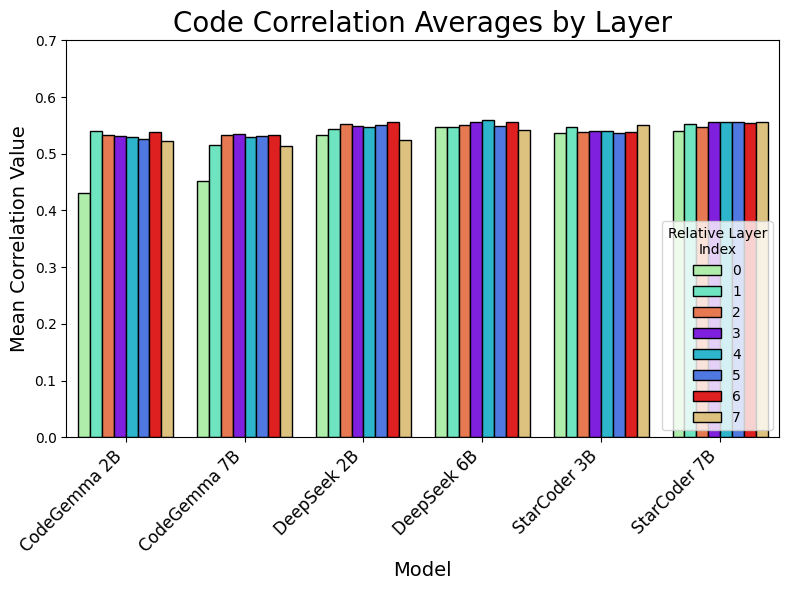

/tmp/ipykernel_2888104/2987988486.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=12)


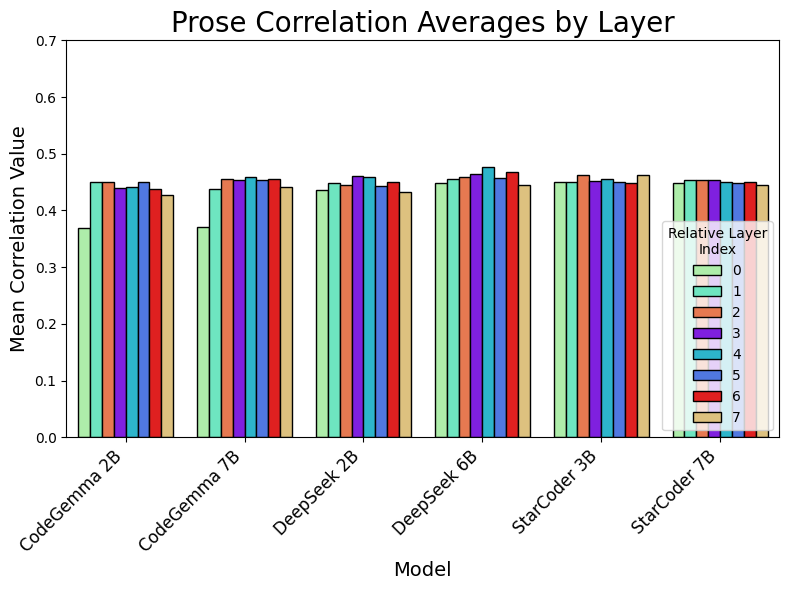

In [12]:
plot_layer_means(code_layer_means, 'Code')
plot_layer_means(prose_layer_means, 'Prose')

In [13]:
from scipy import stats

compute_layer_stats(code_layer_means, 'code')
compute_layer_stats(code_layer_means, 'prose')

code
CodeGemma 2B ($F=0.657$, $p=0.708$)
CodeGemma 7B ($F=0.513$, $p=0.824$)
DeepSeek 2B ($F=0.032$, $p=1.000$)
DeepSeek 6B ($F=0.019$, $p=1.000$)
StarCoder 3B ($F=0.012$, $p=1.000$)
StarCoder 7B ($F=0.015$, $p=1.000$)
prose
CodeGemma 2B ($F=1.443$, $p=0.191$)
CodeGemma 7B ($F=0.883$, $p=0.521$)
DeepSeek 2B ($F=0.115$, $p=0.997$)
DeepSeek 6B ($F=0.051$, $p=1.000$)
StarCoder 3B ($F=0.030$, $p=1.000$)
StarCoder 7B ($F=0.075$, $p=0.999$)
